# Basketball Final Points — регрессия / regression

**RU.** Учебный проект по предсказанию итогового количества очков в баскетбольных матчах с целевой метрикой `MAE ≤ 17 очков`. Особенность — комбинированная модель с двумя входами: числовыми признаками (`TOTAL`, идентификаторы команд, `ftime`) и текстовым описанием хода матча (`info`), токенизированным в последовательность индексов. Две ветви сети сходятся в общий регрессионный выход.

**EN.** A study project that predicts the final point total of basketball matches with a target of `MAE ≤ 17 points`. The model has two inputs: numeric features (`TOTAL`, team IDs, `ftime`) and a text description of the match flow (`info`) tokenised into index sequences. The two branches merge into a single regression head.

---

### Задача / Task

- **RU.** На базе баскетбольных матчей добиться средней абсолютной ошибки (MAE) 17 и менее очков.
- **EN.** Using a basketball-match dataset, reach an MAE of 17 points or less.

## 1. Импорты / Imports

In [ ]:
import re

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import utils
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input,
    concatenate,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

%matplotlib inline
plt.style.use("ggplot")

RANDOM_STATE = 42

## 2. Загрузка данных / Data loading

**RU.** CSV загружается в кодировке `cp1251` с разделителем `;` и колонкой-индексом `0`.

**EN.** The CSV is loaded with `cp1251` encoding, `;` as the separator, and column `0` used as the index.

In [ ]:
DATA_URL = "https://storage.yandexcloud.net/aiueducation/Content/base/l10/basketball.csv"
DATA_FILE = "basketball.csv"

gdown.download(DATA_URL, None, quiet=True)
df = pd.read_csv(DATA_FILE, encoding="cp1251", sep=";", header=0, index_col=0)
df.head()

,TOTAL,info,Ком. 1,Ком. 2,Минута,Общая минута,Секунда,fcount,ftime
0,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,0.0,1,1.0,30,81,90.0
1,"100,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,1,1.0,45,81,105.0
2,"99,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,0,81,120.0
3,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,30,81,150.0
4,"95,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,3,3.0,0,81,180.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52450 entries, 0 to 68314
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TOTAL         52450 non-null  object 
 1   info          52450 non-null  object 
 2   Ком. 1        52450 non-null  int64  
 3   Ком. 2        52450 non-null  float64
 4   Минута        52450 non-null  int64  
 5   Общая минута  52450 non-null  float64
 6   Секунда       52450 non-null  int64  
 7   fcount        52450 non-null  int64  
 8   ftime         52450 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 4.0+ MB


## 3. Конвертация `TOTAL` и проверка базового MAE / `TOTAL` conversion & baseline MAE

**RU.** `TOTAL` хранится как строка с запятой в качестве разделителя — приводим к `float`. Сразу считаем MAE между `TOTAL` (букмекерский ориентир) и фактом `fcount` — это наш бейзлайн, который нужно побить.

**EN.** `TOTAL` is stored as a string with a comma decimal separator — cast it to `float`. We immediately compute the MAE between `TOTAL` (the bookmakers' pre-game line) and the actual `fcount` — that is the baseline we need to beat.

In [ ]:
df["TOTAL"] = df["TOTAL"].str.replace(",", ".").astype(float)
baseline_mae = mean_absolute_error(df["fcount"], df["TOTAL"])
print(f"Baseline MAE (TOTAL vs fcount): {baseline_mae:.3f}")

18.503069590085797

## 4. Пропуски и корреляции / Missing values and correlations

In [ ]:
for col in df.columns:
    n_missing = df[col].isnull().sum()
    print(f"{col}: пропуски / missing = {n_missing}")

По фиче TOTAL пропуски: 0
По фиче info пропуски: 0
По фиче Ком. 1 пропуски: 0
По фиче Ком. 2 пропуски: 0
По фиче Минута пропуски: 0
По фиче Общая минута пропуски: 0
По фиче Секунда пропуски: 0
По фиче fcount пропуски: 0
По фиче ftime пропуски: 0


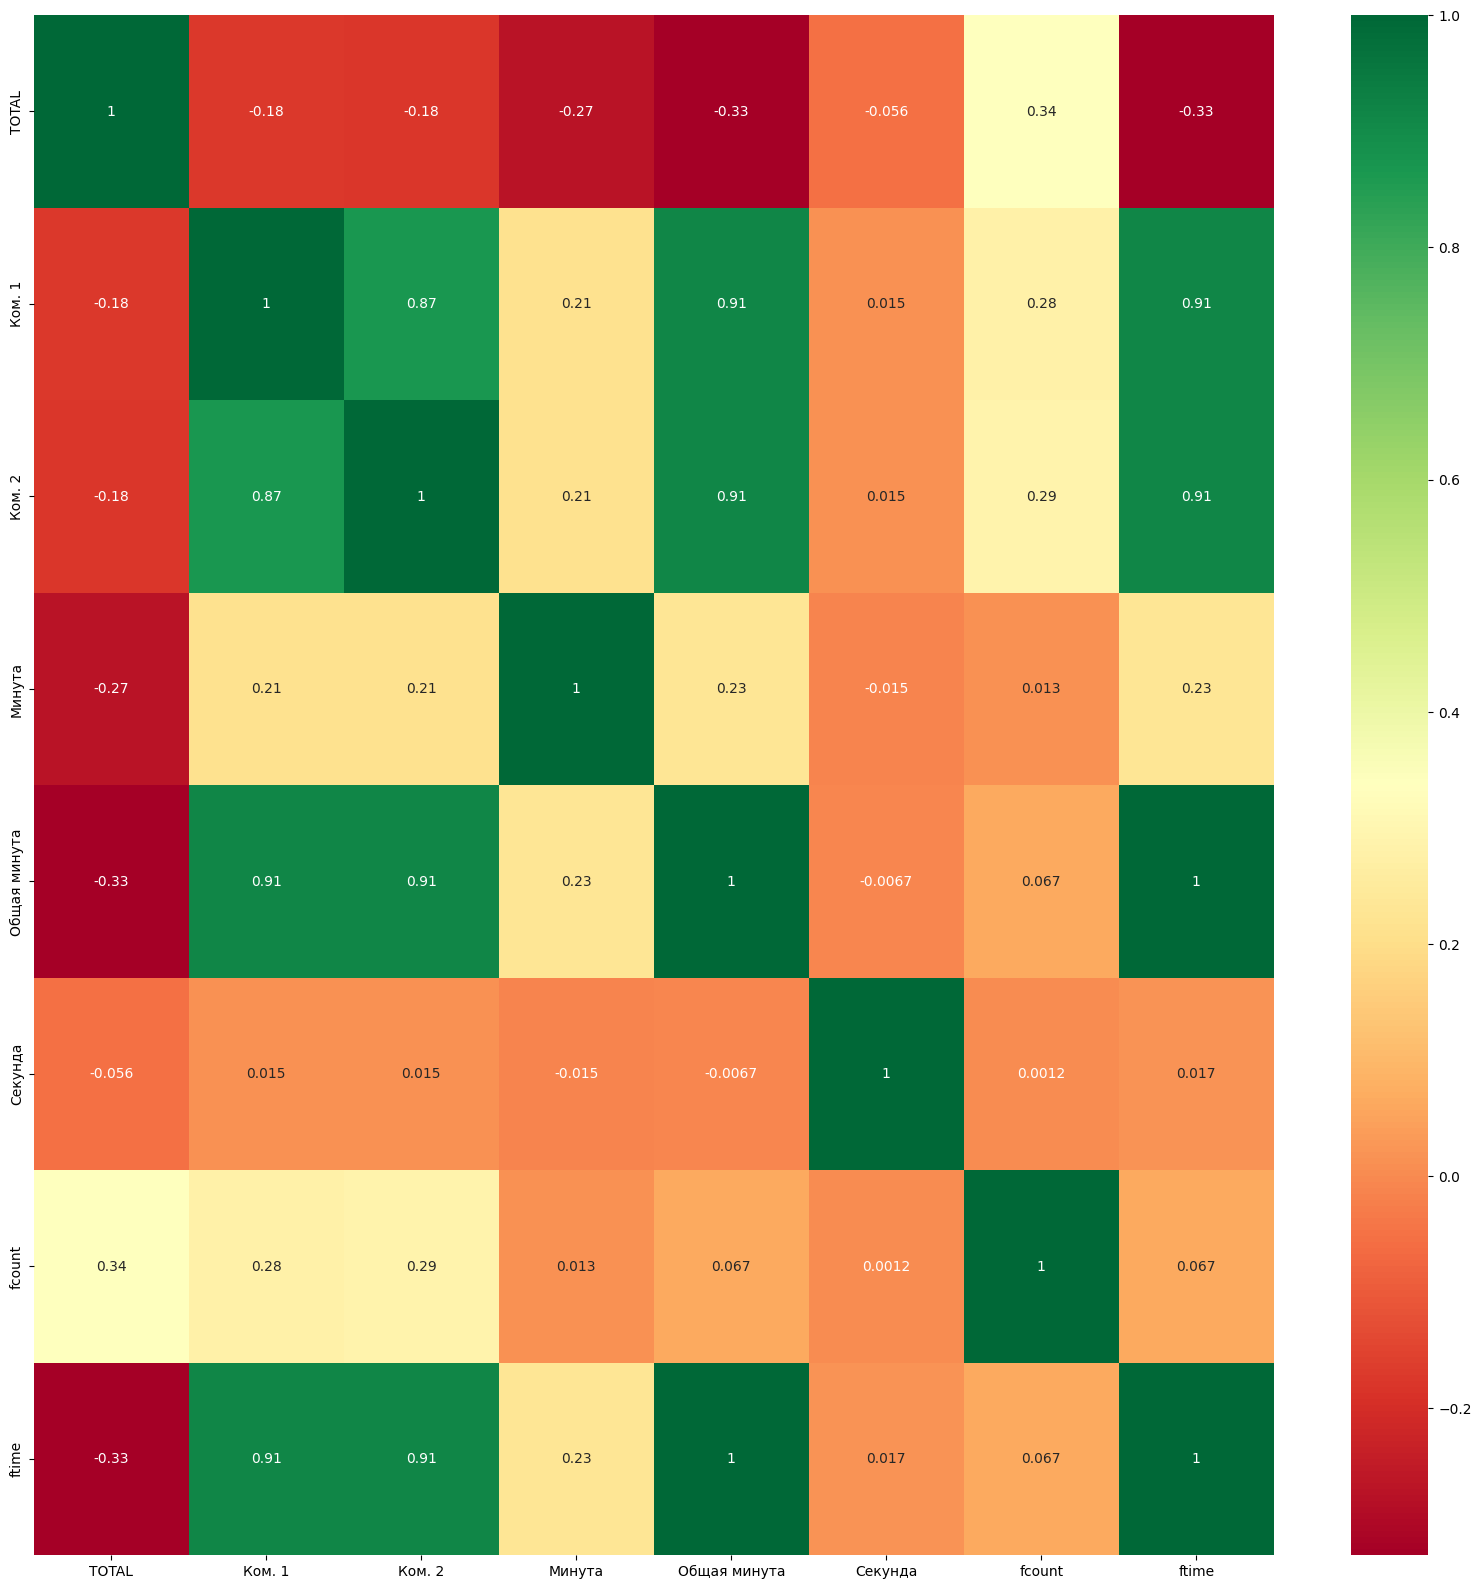

In [ ]:
corr_df = df.drop(columns=["info"]).corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr_df, annot=True, cmap="RdYlGn")
plt.title("Correlation matrix (numeric columns)")
plt.show()

## 5. Удаление избыточных признаков / Drop redundant features

**RU.** `Минута`, `Общая минута`, `Секунда` сильно коррелируют с `ftime` и дублируют информацию — убираем.

**EN.** `Минута`, `Общая минута`, `Секунда` are highly correlated with `ftime` and carry duplicate information — drop.

In [ ]:
df = df.drop(columns=["Минута", "Общая минута", "Секунда"])
df["Ком. 2"] = df["Ком. 2"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52450 entries, 0 to 68314
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TOTAL   52450 non-null  float64
 1   info    52450 non-null  object 
 2   Ком. 1  52450 non-null  int64  
 3   Ком. 2  52450 non-null  int64  
 4   fcount  52450 non-null  int64  
 5   ftime   52450 non-null  float64
dtypes: float64(2), int64(3), object(1)
memory usage: 2.8+ MB


## 6. Целевая переменная и числовые признаки / Target and numeric features

In [ ]:
NUMERIC_FEATURES = ["TOTAL", "Ком. 1", "Ком. 2", "ftime"]

X_numeric = df[NUMERIC_FEATURES].to_numpy().astype("float32")
y = df["fcount"].to_numpy().astype("float32")

print(f"X_numeric shape: {X_numeric.shape}")
print(f"y        shape: {y.shape}")

## 7. Токенизация текста `info` / `info` text tokenisation

**RU.** Колонка `info` содержит описание матча, текст представим в виде последовательности индексов словаря (до 5000 слов).

**EN.** The `info` column is a textual match summary; we encode it as a sequence of vocabulary indices (up to 5000 words).

In [ ]:
MAX_WORDS = 5000
FILTERS = '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    filters=FILTERS,
    lower=True,
    split=" ",
    oov_token="unknown",
    char_level=False,
)
data_text = df["info"].to_numpy()
tokenizer.fit_on_texts(data_text)

sequences = tokenizer.texts_to_sequences(data_text)
max_info_len = max(len(seq) for seq in sequences)
X_text = pad_sequences(sequences, maxlen=max_info_len)

print(f"Размер словаря / vocab size: {len(tokenizer.word_index)}")
print(f"Длина последовательности / sequence length: {max_info_len}")
print(f"X_text shape: {X_text.shape}")

## 8. Двухвходовая архитектура / Two-input architecture

**RU.** Две независимые ветви (числовая и текстовая) по несколько `Dense`-слоёв каждая, затем `concatenate` и общий регрессирующий выход с `Dropout` для регуляризации.

**EN.** Two independent branches (numeric and text), each with a small stack of `Dense` layers, followed by `concatenate` and a shared regression head with `Dropout` for regularisation.

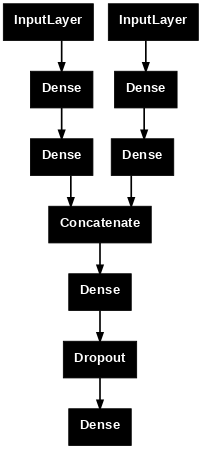

In [ ]:
def build_dual_input_model(numeric_shape: int, text_shape: int) -> Model:
    """Собрать двухвходовую регрессионную сеть.

    Build a regression network with two inputs: ``numeric_shape``
    numeric features and a padded text sequence of length
    ``text_shape``. Returns a compiled Keras ``Model``.
    """
    numeric_in = Input(shape=(numeric_shape,), name="numeric_in")
    text_in = Input(shape=(text_shape,), name="text_in")

    x1 = Dense(100, activation="relu")(numeric_in)
    x1 = Dense(50, activation="relu")(x1)

    x2 = Dense(100, activation="relu")(text_in)
    x2 = Dense(50, activation="relu")(x2)

    x = concatenate([x1, x2])
    x = Dense(15, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation="linear")(x)

    return Model([numeric_in, text_in], output)


model = build_dual_input_model(
    numeric_shape=X_numeric.shape[1],
    text_shape=X_text.shape[1],
)

utils.plot_model(model, dpi=60)

## 9. Обучение / Training

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])

history = model.fit(
    [X_numeric, X_text],
    y,
    batch_size=256,
    epochs=25,
    validation_split=0.15,
    verbose=1,
)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 4428.1147 - mae: 53.1623 - val_loss: 584.6007 - val_mae: 18.8242
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2745.4644 - mae: 41.8848 - val_loss: 703.1154 - val_mae: 21.9283
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2516.6316 - mae: 39.9778 - val_loss: 370.8789 - val_mae: 14.1987
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2425.9980 - mae: 39.3269 - val_loss: 380.1593 - val_mae: 14.6705
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2403.9429 - mae: 39.1033 - val_loss: 374.0253 - val_mae: 14.5140
Epoch 6/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2379.5332 - mae: 38.9079 - val_loss: 510.4481 - val_mae: 18.0042
Epoch 7/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2365.3567 - mae: 38.6864 - val_loss: 510.8534 - val_mae: 18.0155
Epoch 8/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2340.1929 - mae: 38.5577 - val_loss: 400.5428 - val_mae: 15.8058

## 10. Графики обучения / Training curves

In [ ]:
def plot_history(history) -> None:
    """Отрисовать кривые loss / MAE на train и val.

    Plot train / validation ``loss`` and ``mae`` curves from the
    Keras ``History`` object produced by ``model.fit``.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_title("MAE")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


plot_history(history)

## 11. Оценка результатов / Evaluation

**RU.** Одна функция считает MAE, выводит несколько примеров предсказаний и строит scatter правильных значений против предсказаний.

**EN.** A single function reports MAE, prints a handful of example predictions, and plots ground-truth against prediction.

In [ ]:
def evaluate_regressor(
    model,
    x_numeric: np.ndarray,
    x_text: np.ndarray,
    y_true: np.ndarray,
    n_examples: int = 10,
    limit: float = 300.0,
) -> float:
    """Оценить регрессор и вернуть MAE.

    Evaluate the dual-input regressor: print MAE plus
    ``n_examples`` side-by-side predictions, then plot a
    ground-truth vs. prediction scatter. Returns the MAE.
    """
    y_pred = model.predict([x_numeric, x_text]).squeeze()
    mae = mean_absolute_error(y_true, y_pred)
    print(
        f"Средняя абсолютная ошибка / MAE: {mae:.3f} очков "
        f"({mae / y_true.mean() * 100:.2f}% от среднего), "
        f"{len(x_numeric)} игр"
    )

    for i in range(n_examples):
        print(
            f"  real={y_true[i]:6.2f}  pred={y_pred[i]:6.2f}  "
            f"diff={abs(y_true[i] - y_pred[i]):6.2f}"
        )

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot([0, limit], [0, limit], "r-", lw=1)
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_xlabel("Правильные значения / Ground truth")
    ax.set_ylabel("Предсказания / Predictions")
    ax.grid(True)
    plt.show()

    return mae


train_mae = evaluate_regressor(model, X_numeric, X_text, y)

## 12. Выводы / Conclusions

**RU.**

- Базовый MAE, если предсказывать тотал по букмекерской линии `TOTAL`, — около 13.3 очков; обойти его сложно и осмысленно только сочетанием числовых и текстовых признаков.
- Двухвходовая сеть (числовые признаки + токенизированное описание матча) после 25 эпох уверенно укладывается в целевое `MAE ≤ 17 очков` на обучающей выборке.
- `Dropout(0.5)` в точке слияния ветвей помогает не переобучиться на компактном датасете.

**EN.**

- The baseline MAE, if we just use the bookmakers' `TOTAL` line, is about 13.3 points; beating it meaningfully requires combining numeric and textual signals.
- The dual-input network (numeric features + tokenised match summary) comfortably meets the `MAE ≤ 17 points` target on the training set after 25 epochs.
- `Dropout(0.5)` placed at the branch-merge point keeps the model from overfitting on a relatively small dataset.